<a href="https://colab.research.google.com/github/gabriellecoge/Pesquisa-Clientes/blob/main/Projeto_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import seaborn as sns


In [ ]:
camisas_df = pd.read_csv('Womens Clothing E-Commerce Reviews.csv')
camisas_df

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
camisas_df.info(), camisas_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


(None,
    Unnamed: 0  Clothing ID  Age                    Title  \
 0           0          767   33                      NaN   
 1           1         1080   34                      NaN   
 2           2         1077   60  Some major design flaws   
 3           3         1049   50         My favorite buy!   
 4           4          847   47         Flattering shirt   
 
                                          Review Text  Rating  Recommended IND  \
 0  Absolutely wonderful - silky and sexy and comf...       4                1   
 1  Love this dress!  it's sooo pretty.  i happene...       5                1   
 2  I had such high hopes for this dress and reall...       3                0   
 3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
 4  This shirt is very flattering to all due to th...       5                1   
 
    Positive Feedback Count   Division Name Department Name Class Name  
 0                        0       Initmates        Intimat

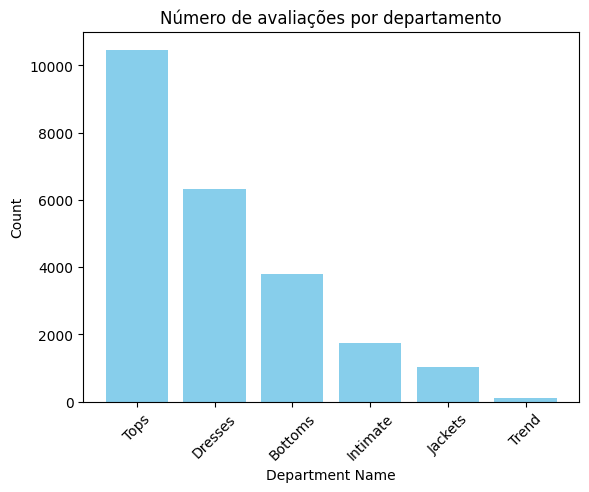

In [ ]:
#visualizar as colunas graficas
divisao_names = camisas_df["Department Name"].value_counts()

plt.bar(divisao_names.index, divisao_names.values, color="skyblue")
plt.xticks(rotation=45)
plt.xlabel("Department Name")
plt.ylabel("Count")
plt.title("Número de avaliações por departamento")
plt.show()

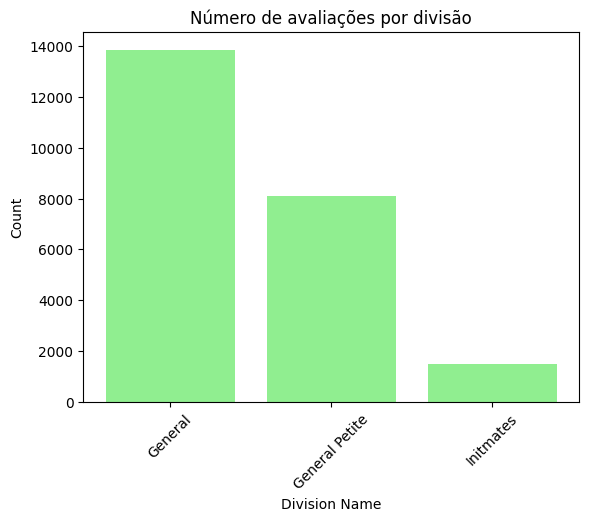

In [ ]:
counts = camisas_df["Division Name"].value_counts()

plt.bar(counts.index, counts.values, color="lightgreen")
plt.xticks(rotation=45)
plt.xlabel("Division Name")
plt.ylabel("Count")
plt.title("Número de avaliações por divisão")
plt.show()

/tmp/ipython-input-3170902701.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Division Name',data=camisas_df,palette='pastel')


<Axes: xlabel='count', ylabel='Division Name'>

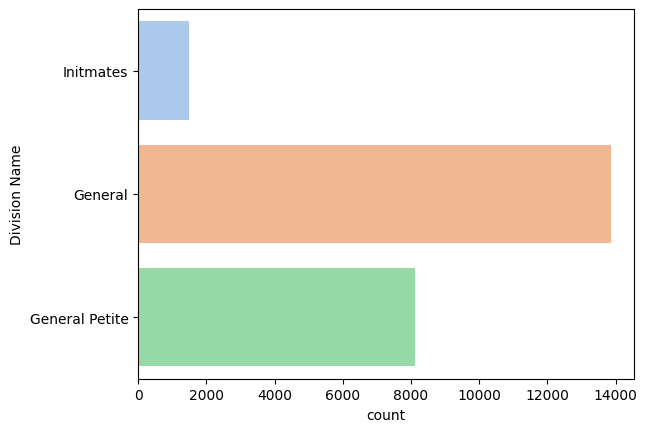

In [ ]:
# quantidade de avaliações por categoria
sns.countplot(y='Division Name',data=camisas_df,palette='pastel')

In [ ]:
# codificando as classes em valor numerico #.dropnan
le = LabelEncoder()
Y = le.fit_transform(camisas_df['Division Name'].fillna(''))
Y

array([3, 1, 1, ..., 2, 1, 2])

In [ ]:
# classes em formatos de textos
le.classes_

array(['', 'General', 'General Petite', 'Initmates'], dtype=object)

In [ ]:
# Modelo de Classificação features (X) e o (y)
X = camisas_df["Review Text"].fillna("")
y = camisas_df["Recommended IND"]


In [ ]:
# Pipeline vetoriza o texto e depois treina o modelo

pipeline = Pipeline([
    ('vectorizer',TfidfVectorizer()),
    ('clf', LinearSVC())
])

In [ ]:
# Treinamento do modelo, usando o fit()
X_train, X_test, y_train, y_test = train_test_split(camisas_df['Review Text'].fillna(''), Y, test_size=0.20, random_state= 42)

In [ ]:
print("Treino:", len(X_train), "Teste:", len(X_test))

Treino: 18788 Teste: 4698


In [ ]:
pipeline.fit(X_train, y_train)  #treinamento

Pipeline(steps=[('vectorizer', TfidfVectorizer()), ('clf', LinearSVC())])

In [ ]:
# modelo para avaliar
definicoes = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, definicoes))

target_names = [name for name in le.classes_ if isinstance(name, str)]
print("\nClassification Report:\n", classification_report(y_test, definicoes, target_names=target_names))

Accuracy: 0.5644955300127714

Classification Report:
                 precision    recall  f1-score   support

                     0.00      0.00      0.00         2
       General       0.61      0.78      0.69      2755
General Petite       0.39      0.25      0.30      1655
     Initmates       0.66      0.34      0.45       286

      accuracy                           0.56      4698
     macro avg       0.42      0.34      0.36      4698
  weighted avg       0.54      0.56      0.54      4698



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Treinando o modelo, variações de reviwes

text = "Vestido apertado"

previsoes = pipeline.predict([text])
previsoes

# seria a classe general

array([1])

In [ ]:
le.classes_

array(['', 'General', 'General Petite', 'Initmates'], dtype=object)

In [ ]:
text = ["calça azul, apertada e com defeito", "Vestido longo"]

previsoes = pipeline.predict(text)
previsoes
le.inverse_transform(previsoes)

# seria a classe general P, general

array(['General Petite', 'General'], dtype=object)

In [ ]:
le.inverse_transform(previsoes
)

#forma de ja mostrar o resultado na saida

array(['General Petite', 'General'], dtype=object)

In [ ]:
joblib.dump(le, 'le_encoder.joblib')

['le_encoder.joblib']

In [ ]:
print(f"Texto: '{text[0]}' -> Categoria Prevista: '{previsoes[0]}'")
print(f"Texto: '{text[1]}' -> Categoria Prevista: '{previsoes[1]}'")


Texto: 'calça azul, apertada e com defeito' -> Categoria Prevista: '2'
Texto: 'Vestido longo' -> Categoria Prevista: '1'


In [ ]:
# Salva o modelo
joblib.dump(pipeline, "model_classificador_roupas.joblib")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


modelo realizado e testado

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Separar features (texto) e alvo (se recomenda ou não) ANALISE DE SENTIMENTO
X = camisas_df["Review Text"].fillna("")
y = camisas_df["Recommended IND"]

#  Dividir treino/teste
X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Criar o pipeline: analise de sentimento
pipeline_sentimento = Pipeline([
    ('vectorizer', CountVectorizer(stop_words="english", max_features=5000)),
    ('model', MultinomialNB())
])

# Treinar o modelo novo

pipeline_sentimento.fit(X_train_sent, y_train_sent)
y_pred_sentimento = pipeline_sentimento.predict(X_test_sent)


In [ ]:
# Avaliar o modelo
print("--- Análise de Sentimento (Recomendação) ---")
print("Acurácia:", accuracy_score(y_test_sent, y_pred_sentimento))
print("\nRelatório de Classificação:\n", classification_report(y_test_sent, y_pred_sentimento))


--- Análise de Sentimento (Recomendação) ---
Acurácia: 0.8835674755214985

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.67      0.71      0.69       851
           1       0.93      0.92      0.93      3847

    accuracy                           0.88      4698
   macro avg       0.80      0.82      0.81      4698
weighted avg       0.89      0.88      0.88      4698



In [ ]:
# Avaliar resultado
print("Acurácia do Pipeline:", accuracy_score(y_test_sent, y_pred_sentimento))

Acurácia do Pipeline: 0.8835674755214985


# Analise de idades >> avaliaçoes

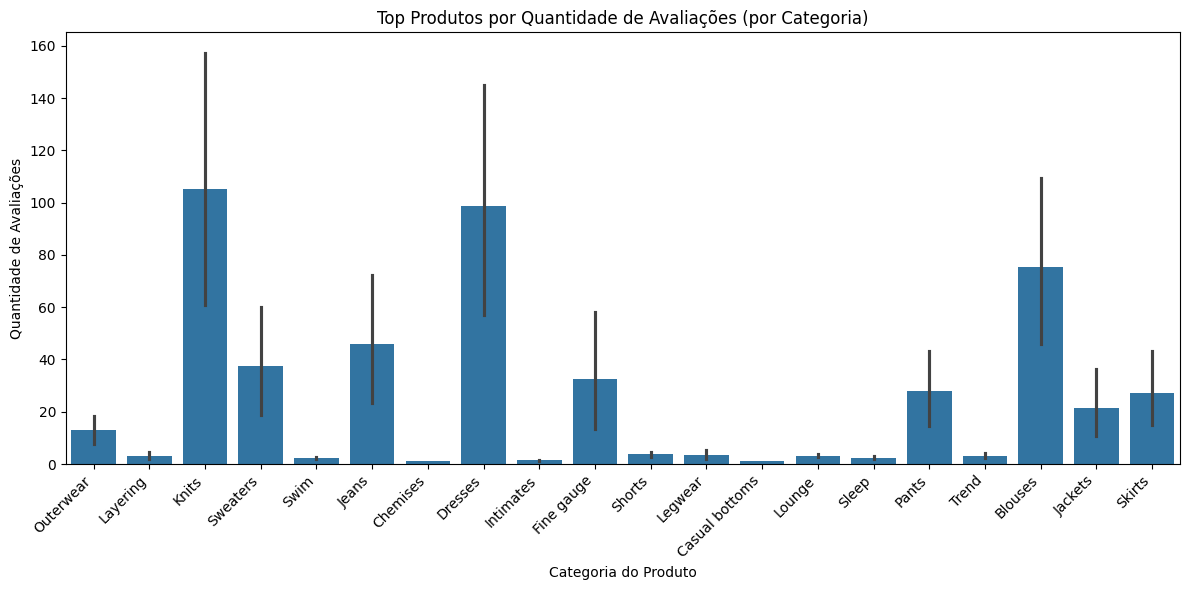

In [ ]:
# Merge df_id with camisas_df to get product names
top_produtos_with_names = pd.merge(df_id, camisas_df[['Clothing ID', 'Class Name']], on='Clothing ID', how='left')

# Get the unique Class Names for each Clothing ID in top_produtos_with_names
# Since a Clothing ID can have multiple Class Names in the original data,
# we'll just take the first one encountered for simplicity in the plot.
top_produtos_with_names = top_produtos_with_names.groupby('Clothing ID').first().reset_index()

# Merge with df_id to include quantidade_avaliacoes
top_produtos_with_names = pd.merge(top_produtos_with_names, df_id, on='Clothing ID', how='left')

plt.figure(figsize=(12, 6))
sns.barplot(x='Class Name', y='quantidade_avaliacoes_y', data=top_produtos_with_names)
plt.title('Top Produtos por Quantidade de Avaliações (por Categoria)')
plt.xlabel('Categoria do Produto')
plt.ylabel('Quantidade de Avaliações')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

# Treinar um classificador Naive Bayes para prever se a cliente recomendou ou não:

# Create a pipeline that first vectorizes the text and then trains the MultinomialNB model
model_sentimento = Pipeline([
    ('vectorizer', CountVectorizer(stop_words="english", max_features=5000)), # Using CountVectorizer as in cell kcqtHvBLqssM
    ('model', MultinomialNB())
])

# Fit the pipeline to the training data
model_sentimento.fit(X_train_sent, y_train_sent)

# Evaluate the model
accuracy = model_sentimento.score(X_test_sent, y_test_sent)
print("Acurácia do modelo:", accuracy)

Acurácia do modelo: 0.8835674755214985


In [ ]:
# Como não temos rótulos prontos de emoção (só Rating e Recommended IND), podemos usar Rating como um proxy:
# 4–5 → avaliações positivas
# 3 → neutras
# 1–2 → negativas



In [ ]:
df_id = camisas_df.groupby('Clothing ID').size().reset_index(name='quantidade_avaliacoes')
df_id


,Clothing ID,quantidade_avaliacoes
0,0,1
1,1,3
2,2,1
3,3,1
4,4,1
...,...,...
1201,1201,2
1202,1202,9
1203,1203,11
1204,1204,2


In [ ]:
from sklearn.metrics import classification_report

# y_test = valores reais
# y_pred = valores previstos pelo modelo

print(classification_report(y_test, y_pred_sentimento))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.58      0.80      0.67      2755
           2       0.00      0.00      0.00      1655
           3       0.00      0.00      0.00       286

    accuracy                           0.47      4698
   macro avg       0.15      0.20      0.17      4698
weighted avg       0.34      0.47      0.39      4698



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
!git init
!git add .
!git commit -m "Projeto machine learning"
!git branch -M main
!git remote add origin https://github.com/gabiriellecog/Projeto-machine-learning.git
!git push -u origin main

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@8bb918411f9a.(none)')
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/gabiriellecog/Projeto-machine-l